# **Mini Project: Security-Aware Text Classifier**
1. **Project Goal**

The classifier will take a text message such as:

- "Congratulations! You won a $1000 prize. Click here now!"
- "Can you send me the meeting notes?"

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

# Create the Dataset

In [2]:
data = {
    "text": [
        "Congratulations! You won a $1000 prize. Click here now!",
        "URGENT! Your account has been selected for a reward. Claim now.",
        "You have won a free vacation. Send your details to receive it.",
        "Your bank account has been suspended. Verify your information immediately.",
        "Click this link to claim your free gift card.",
        "You are the lucky winner of a cash prize!",
        "Your password will expire today. Click the link to verify.",
        "Congratulations, you have won a lottery. Contact us immediately.",
        "Urgent security alert! Verify your account now.",
        "You have been selected for a special offer. Click here.",

        "Hi, are we still meeting at 3 PM?",
        "Please send me the project report.",
        "Your appointment is confirmed for tomorrow.",
        "Can you call me when you are free?",
        "The meeting has been moved to Monday.",
        "Please review the assignment before submitting it.",
        "I will send the files this evening.",
        "Thank you for your help with the project.",
        "Let's discuss the project tomorrow.",
        "The class will start at 10 AM."
    ],
    
    "label": [
        "spam",
        "spam",
        "spam",
        "spam",
        "spam",
        "spam",
        "spam",
        "spam",
        "spam",
        "spam",
        
        "legitimate",
        "legitimate",
        "legitimate",
        "legitimate",
        "legitimate",
        "legitimate",
        "legitimate",
        "legitimate",
        "legitimate",
        "legitimate"
    ]
}

df = pd.DataFrame(data)

df.head()

,text,label
0,Congratulations! You won a $1000 prize. Click ...,spam
1,URGENT! Your account has been selected for a r...,spam
2,You have won a free vacation. Send your detail...,spam
3,Your bank account has been suspended. Verify y...,spam
4,Click this link to claim your free gift card.,spam


In [3]:
# Check the Dataset

print("Dataset shape:", df.shape)

print("\nClass distribution:")
print(df["label"].value_counts())

Dataset shape: (20, 2)

Class distribution:
label
spam          10
legitimate    10
Name: count, dtype: int64


In [4]:
# Basic Text Cleaning

def clean_text(text):
    text = str(text).lower()
    
    # Remove URLs
    text = re.sub(r"http\S+|www\S+", " ", text)
    
    # Remove special characters
    text = re.sub(r"[^a-zA-Z0-9\s]", " ", text)
    
    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()
    
    return text

In [5]:
df["clean_text"] = df["text"].apply(clean_text)

df[["text", "clean_text"]].head()

,text,clean_text
0,Congratulations! You won a $1000 prize. Click ...,congratulations you won a 1000 prize click her...
1,URGENT! Your account has been selected for a r...,urgent your account has been selected for a re...
2,You have won a free vacation. Send your detail...,you have won a free vacation send your details...
3,Your bank account has been suspended. Verify y...,your bank account has been suspended verify yo...
4,Click this link to claim your free gift card.,click this link to claim your free gift card


In [6]:
# Convert Labels into Numbers

df["target"] = df["label"].map({
    "legitimate": 0,
    "spam": 1
})

df[["text", "label", "target"]].head()

,text,label,target
0,Congratulations! You won a $1000 prize. Click ...,spam,1
1,URGENT! Your account has been selected for a r...,spam,1
2,You have won a free vacation. Send your detail...,spam,1
3,Your bank account has been suspended. Verify y...,spam,1
4,Click this link to claim your free gift card.,spam,1


In [7]:
# split the dataset into training and testing sets
X = df["clean_text"]
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split( X, y,test_size=0.30,
                                                   random_state=42,stratify=y)
                                                   
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 14
Testing samples: 6


In [8]:
# Convert Text into Numerical Features and we used TF-IDF (Term Frequency-Inverse Document Frequency) vectorization to convert the text data into numerical features that can be used by machine learning algorithms.

vectorizer = TfidfVectorizer(
    max_features=1000,
    ngram_range=(1, 2)
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

In [9]:
# Train the Classifier
model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [12]:
# Make Predictions
y_pred = model.predict(X_test_tfidf)

print("Predictions:")
print(y_pred)

Predictions:
[1 1 1 1 1 0]


In [13]:
# Evaluate the Model
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

# Classification Report give the precision, recall, f1-score, and support for each class in the classification task. It provides a detailed overview of the model's performance across different metrics.
print(classification_report(
    y_test,
    y_pred,
    target_names=["Legitimate", "Spam/Phishing"],
    zero_division=0
))


Accuracy: 0.6666666666666666
               precision    recall  f1-score   support

   Legitimate       1.00      0.33      0.50         3
Spam/Phishing       0.60      1.00      0.75         3

     accuracy                           0.67         6
    macro avg       0.80      0.67      0.62         6
 weighted avg       0.80      0.67      0.62         6



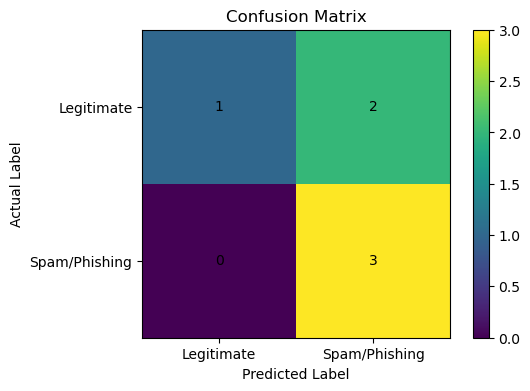

In [15]:
# confusion matrix is a table that is often used to describe the performance of a classification model on a set of test data for which the true values are known. It allows us to visualize the performance of the model by showing the counts of true positive, true negative, false positive, and false negative predictions.
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
plt.imshow(cm)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.xticks(
    [0, 1],
    ["Legitimate", "Spam/Phishing"]
)

plt.yticks(
    [0, 1],
    ["Legitimate", "Spam/Phishing"]
)

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()
plt.show()

In [16]:
# Create a Security-Aware Input Validation Function
def validate_input(text):
    # Check that input is a string
    if not isinstance(text, str):
        return False, "Input must be text."
    
    # Remove leading/trailing spaces
    text = text.strip()
    
    # Reject empty input
    if not text:
        return False, "Input cannot be empty."
    
    # Limit input length
    if len(text) > 1000:
        return False, "Input is too long. Maximum length is 1000 characters."
    
    # Reject excessive null bytes
    if "\x00" in text:
        return False, "Invalid characters detected."
    
    return True, text

In [18]:
message = "Congratulations! You won a $5000 prize. Click here now!"

print(predict_message(message))

SPAM / PHISHING | Confidence: 62.05%


In [17]:
# Create a Safe Prediction Function
def predict_message(text):
    # Validate input
    is_valid, result = validate_input(text)
    
    if not is_valid:
        return result
    
    # Clean the text
    cleaned = clean_text(result)
    
    # Convert text into TF-IDF
    text_vector = vectorizer.transform([cleaned])
    
    # Predict
    prediction = model.predict(text_vector)[0]
    
    # Probability
    probability = model.predict_proba(text_vector)[0].max()
    
    if prediction == 1:
        label = "SPAM / PHISHING"
    else:
        label = "LEGITIMATE"
    
    return f"{label} | Confidence: {probability:.2%}"

In [19]:
message = "Hi, please send me the project report."

print(predict_message(message))

LEGITIMATE | Confidence: 63.62%


In [21]:
# Test the multiple lines messages
test_messages = [
    "Congratulations! You have won a free iPhone. Click now!",
    "Please send me the assignment.",
    "URGENT! Verify your bank account immediately.",
    "Can you join the meeting at 2 PM?",
    "You are selected for a $10,000 reward. Claim now!"
]

for message in test_messages:
    print("Message:", message)
    print("Result :", predict_message(message))
    print("-" * 60)

Message: Congratulations! You have won a free iPhone. Click now!
Result : SPAM / PHISHING | Confidence: 61.03%
------------------------------------------------------------
Message: Please send me the assignment.
Result : LEGITIMATE | Confidence: 60.54%
------------------------------------------------------------
Message: URGENT! Verify your bank account immediately.
Result : SPAM / PHISHING | Confidence: 60.36%
------------------------------------------------------------
Message: Can you join the meeting at 2 PM?
Result : LEGITIMATE | Confidence: 57.62%
------------------------------------------------------------
Message: You are selected for a $10,000 reward. Claim now!
Result : SPAM / PHISHING | Confidence: 55.95%
------------------------------------------------------------
